#Extracción

In [1]:
import requests

url = "https://raw.githubusercontent.com/lauralara13021/ETL-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()

In [3]:
type(data)

list

In [6]:
len(data)

7267

# Transform

In [7]:
import pandas as pd
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [9]:
df["customer"].iloc[0]

{'gender': 'Female',
 'SeniorCitizen': 0,
 'Partner': 'Yes',
 'Dependents': 'Yes',
 'tenure': 9}

In [11]:
customer_df = pd.json_normalize(df["customer"])
customer_df

,gender,SeniorCitizen,Partner,Dependents,tenure
0,Female,0,Yes,Yes,9
1,Male,0,No,No,9
2,Male,0,No,No,4
3,Male,1,Yes,No,13
4,Female,1,Yes,No,3
...,...,...,...,...,...
7262,Female,0,No,No,13
7263,Male,0,Yes,No,22
7264,Male,0,No,No,2
7265,Male,0,Yes,Yes,67


In [12]:
phone_df = pd.json_normalize(df["phone"])
phone_df

,PhoneService,MultipleLines
0,Yes,No
1,Yes,Yes
2,Yes,No
3,Yes,No
4,Yes,No
...,...,...
7262,Yes,No
7263,Yes,Yes
7264,Yes,No
7265,Yes,No


In [13]:
internet_df = pd.json_normalize(df["internet"])
internet_df

,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,DSL,No,Yes,No,Yes,Yes,No
1,DSL,No,No,No,No,No,Yes
2,Fiber optic,No,No,Yes,No,No,No
3,Fiber optic,No,Yes,Yes,No,Yes,Yes
4,Fiber optic,No,No,No,Yes,Yes,No
...,...,...,...,...,...,...,...
7262,DSL,Yes,No,No,Yes,No,No
7263,Fiber optic,No,No,No,No,No,Yes
7264,DSL,No,Yes,No,No,No,No
7265,DSL,Yes,No,Yes,Yes,No,Yes


In [14]:
account_df = pd.json_normalize(df["account"])
account_df

,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,One year,Yes,Mailed check,65.60,593.3
1,Month-to-month,No,Mailed check,59.90,542.4
2,Month-to-month,Yes,Electronic check,73.90,280.85
3,Month-to-month,Yes,Electronic check,98.00,1237.85
4,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...
7262,One year,No,Mailed check,55.15,742.9
7263,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,Month-to-month,Yes,Mailed check,50.30,92.75
7265,Two year,No,Mailed check,67.85,4627.65


In [15]:
df = df.drop(columns=["customer","phone","internet","account"])

In [16]:
df = pd.concat([df, customer_df, phone_df, internet_df, account_df], axis=1)

In [17]:
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df["InternetService"].value_counts()

,count
InternetService,
Fiber optic,3198
DSL,2488
No,1581


In [20]:
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

In [21]:
df["Churn"].value_counts()

,count
Churn,
0.0,5174
1.0,1869


In [22]:
df

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0.0,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,1.0,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,0.0,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,0.0,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [23]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

In [25]:
df["Cuentas_Diarias"] = df["Charges.Monthly"] / 30

In [26]:
df["Cuentas_Diarias"]

,Cuentas_Diarias
0,2.186667
1,1.996667
2,2.463333
3,3.266667
4,2.796667
...,...
7262,1.838333
7263,2.836667
7264,1.676667
7265,2.261667


In [27]:
df["Cuentas_Diarias"].describe()

,Cuentas_Diarias
count,7267.000000
mean,2.157337
std,1.004319
min,0.608333
25%,1.180833
50%,2.343333
75%,2.995833
max,3.958333


#Carga y análisis

In [28]:
df.describe()

,Churn,SeniorCitizen,tenure,Charges.Monthly,Cuentas_Diarias
count,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.265370,0.162653,32.346498,64.720098,2.157337
std,0.441561,0.369074,24.571773,30.129572,1.004319
min,0.000000,0.000000,0.000000,18.250000,0.608333
25%,0.000000,0.000000,9.000000,35.425000,1.180833
50%,0.000000,0.000000,29.000000,70.300000,2.343333
75%,1.000000,0.000000,55.000000,89.875000,2.995833
max,1.000000,1.000000,72.000000,118.750000,3.958333


In [29]:
df["Churn"].value_counts()

,count
Churn,
0.0,5174
1.0,1869


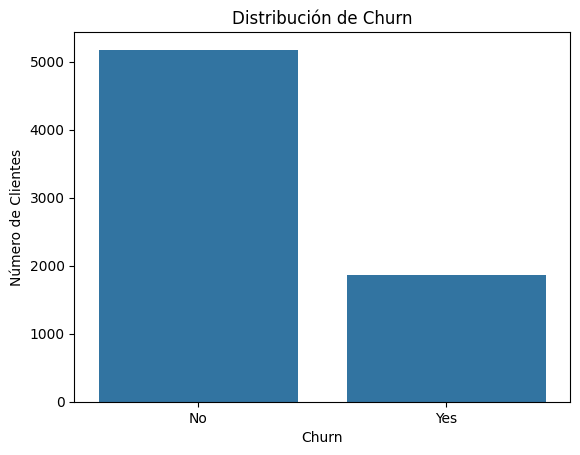

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["Churn"].map({0:"No", 1:"Yes"}))

plt.title("Distribución de Churn")
plt.xlabel("Churn")
plt.ylabel("Número de Clientes")

plt.show()

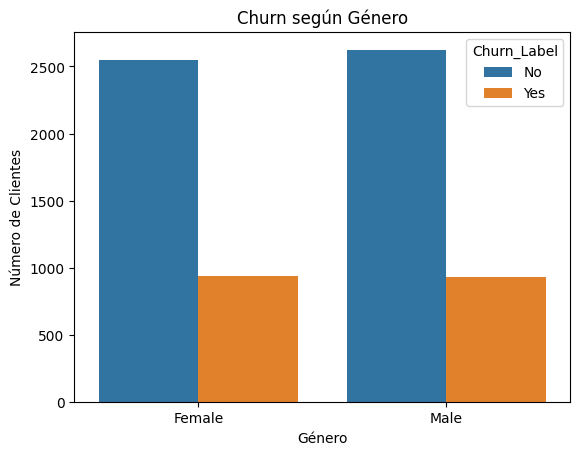

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
df["Churn_Label"] = df["Churn"].map({0:"No", 1:"Yes"})
sns.countplot(x="gender", hue="Churn_Label", data=df)

plt.title("Churn según Género")
plt.xlabel("Género")
plt.ylabel("Número de Clientes")

plt.show()

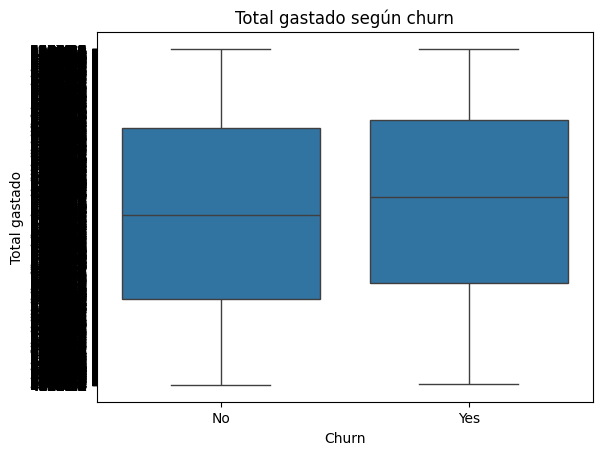

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Churn_Label", y="Charges.Total", data=df)

plt.title("Total gastado según churn")
plt.xlabel("Churn")
plt.ylabel("Total gastado")

plt.show()

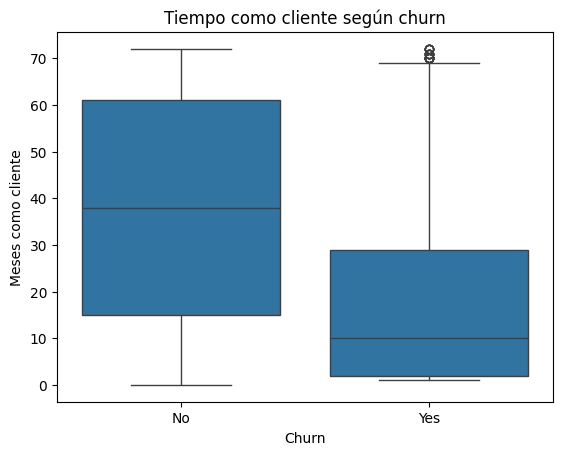

In [36]:
sns.boxplot(x="Churn_Label", y="tenure", data=df)

plt.title("Tiempo como cliente según churn")
plt.xlabel("Churn")
plt.ylabel("Meses como cliente")

plt.show()

In [37]:
corr = df.corr(numeric_only=True)

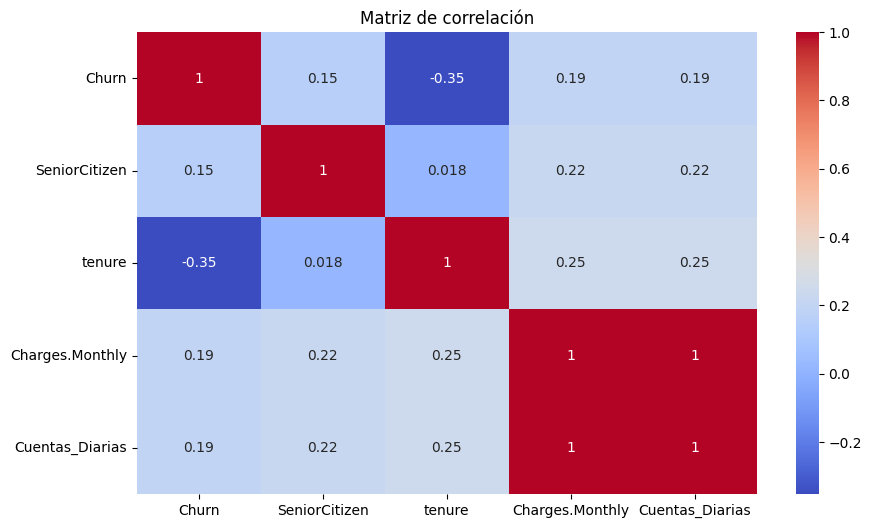

In [38]:
plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Matriz de correlación")

plt.show()

#Informe final

El churn o evasión de clientes representa uno de los principales desafíos para las empresas que ofrecen servicios por suscripción. Cuando un cliente decide cancelar el servicio, la empresa pierde ingresos futuros y debe invertir recursos adicionales para adquirir nuevos clientes. El objetivo de este análisis es explorar los datos de clientes de una empresa de telecomunicaciones para comprender los factores asociados con la evasión. A través del análisis exploratorio de datos, se busca identificar patrones en el comportamiento de los clientes que puedan ayudar a explicar por qué algunos abandonan el servicio mientras que otros permanecen.A partir del análisis realizado, se identificaron varios factores que parecen estar asociados con el churn de clientes. En primer lugar, el tipo de contrato tiene un impacto significativo en la probabilidad de evasión. Los clientes con contratos mensuales presentan tasas de churn considerablemente mayores que aquellos con contratos anuales o de largo plazo.
En segundo lugar, el tiempo de permanencia del cliente en la empresa parece ser un factor relevante. Los clientes más nuevos muestran mayor probabilidad de cancelar el servicio, lo que indica que la etapa inicial de la relación con el cliente es clave.
Por último, los patrones de gasto también pueden proporcionar señales sobre el comportamiento del cliente, lo que puede ser útil para desarrollar modelos predictivos que identifiquen clientes con alto riesgo de abandono.

In [39]:
df.to_csv("churn_cleaned.csv", index=False)

In [42]:
from google.colab import files

# Guarda el CSV primero
df.to_csv("churn_cleaned.csv", index=False)

# Descarga automática
files.download("churn_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>